---

# Quantum Circuits in Action: Defending Neural Networks from Adversarial Attacks

<span style="color: #008800">**Navid Azimi, Aditya Prakash, and Li Xiong**</span>


📁 Datasets: [MNIST](https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html) | [CIFAR-10](https://pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) | [OrganAMNIST](https://medmnist.com/)


📌 Our project explores the adversarial robustness of classical Convolutional Neural Networks and Quanvolutional Neural Networks. Using the Torchattacks and ART libraries, adversarial attack methods will be applied to the models, while the PennyLane library will be used to design and train QNNs. The implementation involves training DNNs, CNNs, and QNNs on several datasets, followed by subjecting them to various adversarial attacks. Our goal is to compare the susceptibility of classical models and quanvolutional models to adversarial perturbations, with a focus on assessing whether quanvolutional neural networks offer increased robustness against adversarial attacks.

---


# 📚 Installing Libraries

In [42]:
# !pip install -r requirements.txt

In [2]:
!pip install torchattacks
!pip install --upgrade pip setuptools wheel
!pip install pennylane
!pip install adversarial-robustness-toolbox
!pip install tabulate
!pip install matplotlib
!pip install medmnist
!pip uninstall torch torchvision -y
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Home\anaconda3\envs\env2\python.exe -m pip install --upgrade pip setuptools wheel


Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [to


---
# 📦 Importing Libraries

In [1]:
import os
import psutil
import shutil
import torch
import torchattacks
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, TensorDataset
import sys
import scipy
import time
import random
import pkg_resources
import importlib
import math
import gzip
import numpy as np
from torchvision.transforms import ToTensor
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import os
from PIL import Image
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import tqdm
import tabulate
from tabulate import tabulate
from art import config
from art.utils import load_dataset, get_file, compute_accuracy
from art.attacks.evasion import CarliniLInfMethod, FastGradientMethod, CarliniL2Method
from art.estimators.classification import PyTorchClassifier, KerasClassifier
from art.estimators.certification.randomized_smoothing import PyTorchRandomizedSmoothing
from medmnist import INFO, OrganAMNIST
import warnings
import importlib.util
import importlib.machinery
from qnn_toolkit import *
from noise_transforms import (
    AddGeometricNoise,
    AddGaussianNoise,
    AddSaltPepperNoise,
    AddOcclusionNoise,
    AddPoissonNoise
)

%matplotlib inline
warnings.filterwarnings("ignore")

C:\Users\Home\AppData\Local\Temp\ipykernel_6068\3644880122.py:16: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
c:\Users\Home\anaconda3\envs\env2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
spec = importlib.util.spec_from_loader(
    "qnn_toolkit",
    importlib.machinery.SourcelessFileLoader("qnn_toolkit", "qnn_toolkit.cpython-312.pyc")
)
qnn_toolkit = importlib.util.module_from_spec(spec)
sys.modules["qnn_toolkit"] = qnn_toolkit
spec.loader.exec_module(qnn_toolkit)
"""

'\nspec = importlib.util.spec_from_loader(\n    "qnn_toolkit",\n    importlib.machinery.SourcelessFileLoader("qnn_toolkit", "qnn_toolkit.cpython-312.pyc")\n)\nqnn_toolkit = importlib.util.module_from_spec(spec)\nsys.modules["qnn_toolkit"] = qnn_toolkit\nspec.loader.exec_module(qnn_toolkit)\n'

---
# 🖥️ System Information

In [3]:
# RAM information
print(f"RAM Info:")
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024 ** 3):.2f} GB")
print(f"Available RAM: {ram.available / (1024 ** 3):.2f} GB\n")

# Disk information
print(f"Disk Info:")
total, used, free = shutil.disk_usage("/")
print(f"Total Disk Space: {total // (2**30)} GB")
print(f"Free Disk Space: {free // (2**30)} GB\n")

# CPU Information
print(f"CPU Info:")
cpu_cores = psutil.cpu_count(logical=False)
cpu_threads = psutil.cpu_count(logical=True)
print(f"Number of Physical Cores: {cpu_cores}")
print(f"Number of Logical Cores: {cpu_threads}")
cpu_info = os.popen("lscpu").read()
print(cpu_info)

# GPU information
print(f"GPU Info:")
print("Available GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f" - GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f" - GPU Memory Total: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

RAM Info:
Total RAM: 15.64 GB
Available RAM: 3.67 GB

Disk Info:
Total Disk Space: 456 GB
Free Disk Space: 192 GB

CPU Info:
Number of Physical Cores: 12
Number of Logical Cores: 16

GPU Info:
Available GPUs: 1
 - GPU 0: NVIDIA GeForce MX570 A
 - GPU Memory Total: 2.00 GB
PyTorch version: 2.5.1+cu121
CUDA version: 12.1



---
# 📌 Options & Parameters - Part One

In [4]:
# Set "CUDA_VISIBLE_DEVICES" to "0" to tell CUDA to only use the first GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [5]:
global device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [6]:
# Select the Ansatz archuitecture from the following: no_entanglement_ansatz, linear_entanglement_ansatz, full_entanglement_ansatz, star_entanglement_ansatz
global entanglement_type
entanglement_type = 'no_entanglement_ansatz'

In [7]:
# Select the dataset from the following: MNIST, CIFAR10, OrganAMNIST
global dataset_name
dataset_name = 'OrganAMNIST'

In [8]:
# Select the Base Neural Network from the following: CNN-MNIST, DNN-MNIST, CNN-CIFAR10, DNN-CIFAR10, CNN-OrganAMNIST, DNN-OrganAMNIST
global NN_name
NN_name = 'DNN-OrganAMNIST'

In [9]:
# Select the noise type from the following: none, gaussian, salt_pepper, occlusion, poisson, geometric
global noise_type
noise_type = "none"

In [10]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'fgsm_attack'

In [11]:
global num_epochs
num_epochs = 10

In [12]:
# Number of classes: 10 for MNIST and CIFAR10 datasets, 11 for OrganAMNIST dataset
global NUM_CLASSES
NUM_CLASSES = 11

In [13]:
# Enable the creation of the QNN model
global construct_qnn_model
construct_qnn_model = False;

In [14]:
# QNN settings
qnn_settings = {
    "output_dim": NUM_CLASSES,                              # output_dim: Output dimension (number of classes)
    "circuit_depth": 1,                                     # circuit_depth: Depth of the quantum circuit
    "noise_strength": 0.005,                                # Initial strength of quantum noise (0.0 to 1.0)
    "input_noise_injection": False,                          # Enable random perturbations to input data
    "entanglement_type": 'no_entanglement_ansatz',      # Type of entanglement to use in the quantum circuit
    "use_dynamic_weights": True,                            # Whether to use dynamic weighting between classical and quantum outputs
    "encoding_method": 'enhanced_angle',                    # Method for encoding classical features into quantum states  ('angle', 'enhanced_angle')
    "noise_model": 'mixed'                                  # Type of noise model to use in quantum simulation ('depolarizing', 'amplitude_damping', 'phase_damping'. 'mixed')
}


---
# 🕸️ The CNN and DNN Models

In [15]:
if NN_name == 'CNN-MNIST':

    class CNN(nn.Module):
        def __init__(self, num_classes=10):
            super().__init__()
            weights = models.ResNet18_Weights.DEFAULT
            self.resnet18 = models.resnet18(weights=weights)
            # Adapt the first conv layer to accept 1 channel
            old_conv = self.resnet18.conv1
            self.resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            # Initialize new conv1 weights as mean of old weights across RGB channels
            with torch.no_grad():
                self.resnet18.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)
            # Adapt output layer
            self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)
            self.logsoftmax = nn.LogSoftmax(dim=1)

        def forward(self, x):
            x = self.resnet18(x)
            return self.logsoftmax(x)

elif NN_name == 'DNN-MNIST':

    class DNN(nn.Module):
        def __init__(self):
            super(DNN, self).__init__()

            # Each MNIST image is 28x28, so the input size is 784
            self.fc1 = nn.Linear(28*28, 512)
            self.bn1 = nn.BatchNorm1d(512)
            self.drop1 = nn.Dropout(0.2)

            self.fc2 = nn.Linear(512, 256)
            self.bn2 = nn.BatchNorm1d(256)
            self.drop2 = nn.Dropout(0.2)

            self.fc3 = nn.Linear(256, 128)
            self.bn3 = nn.BatchNorm1d(128)
            self.drop3 = nn.Dropout(0.2)

            # Output layer for 10 classes
            self.fc4 = nn.Linear(128, 10)

        def forward(self, x):
            # Flatten 28x28 images to 784-dimensional vectors
            x = x.view(x.size(0), -1)

            # 1st layer: FC -> BN -> ReLU -> Dropout
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.drop1(x)

            # 2nd layer
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.drop2(x)

            # 3rd layer
            x = F.relu(self.bn3(self.fc3(x)))
            x = self.drop3(x)

            # Output layer (log_softmax for classification)
            x = self.fc4(x)
            return F.log_softmax(x, dim=1)

elif NN_name == 'CNN-CIFAR10':

    class CNN(nn.Module):
        def __init__(self, num_classes=10):
            super().__init__()
            weights = models.ResNet18_Weights.DEFAULT
            self.resnet18 = models.resnet18(weights=weights)
            # Change the final fully connected layer for CIFAR-10 (10 classes)
            self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)
            self.logsoftmax = nn.LogSoftmax(dim=1)

        def forward(self, x):
            x = self.resnet18(x)
            return self.logsoftmax(x)

elif NN_name == 'DNN-CIFAR10':

    class DNN(nn.Module):
        def __init__(self):
            super(DNN, self).__init__()

            # Each CIFAR-10 image is 3 x 32 x 32, so the input size is 3072
            self.fc1 = nn.Linear(32*32*3, 1024)
            self.bn1 = nn.BatchNorm1d(1024)
            self.drop1 = nn.Dropout(0.2)

            self.fc2 = nn.Linear(1024, 512)
            self.bn2 = nn.BatchNorm1d(512)
            self.drop2 = nn.Dropout(0.2)

            self.fc3 = nn.Linear(512, 256)
            self.bn3 = nn.BatchNorm1d(256)
            self.drop3 = nn.Dropout(0.2)

            self.fc4 = nn.Linear(256, 128)
            self.bn4 = nn.BatchNorm1d(128)
            self.drop4 = nn.Dropout(0.2)

            # Output layer for 10 classes in CIFAR-10
            self.fc5 = nn.Linear(128, 10)

        def forward(self, x):
            # Flatten the 3D input to a 1D vector
            x = x.view(x.size(0), -1)

            # First layer
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.drop1(x)

            # Second layer
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.drop2(x)

            # Third layer
            x = F.relu(self.bn3(self.fc3(x)))
            x = self.drop3(x)

            # Fourth layer
            x = F.relu(self.bn4(self.fc4(x)))
            x = self.drop4(x)

            # Output layer
            x = self.fc5(x)
            return F.log_softmax(x, dim=1)

elif NN_name == 'CNN-OrganAMNIST':

    class CNN(nn.Module):
        def __init__(self, num_classes=11):
            super().__init__()
            weights = models.ResNet18_Weights.DEFAULT
            self.resnet18 = models.resnet18(weights=weights)
            # Adapt the first conv layer for 1-channel (grayscale) OrganAMNIST images
            old_conv = self.resnet18.conv1
            self.resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            with torch.no_grad():
                self.resnet18.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)
            self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)
            self.logsoftmax = nn.LogSoftmax(dim=1)

        def forward(self, x):
            x = self.resnet18(x)
            return self.logsoftmax(x)

elif NN_name == 'DNN-OrganAMNIST':

    class DNN(nn.Module):
        def __init__(self):
            super(DNN, self).__init__()

            # Each OrganAMNIST image is 28x28, so the input size is 784
            self.fc1 = nn.Linear(28*28, 512)
            self.bn1 = nn.BatchNorm1d(512)
            self.drop1 = nn.Dropout(0.2)

            self.fc2 = nn.Linear(512, 256)
            self.bn2 = nn.BatchNorm1d(256)
            self.drop2 = nn.Dropout(0.2)

            self.fc3 = nn.Linear(256, 128)
            self.bn3 = nn.BatchNorm1d(128)
            self.drop3 = nn.Dropout(0.2)

            # Output layer for 11 classes in OrganAMNIST
            self.fc4 = nn.Linear(128, 11)

        def forward(self, x):
            # Flatten 28x28 images to 784-dimensional vectors
            x = x.view(x.size(0), -1)

            # 1st layer: FC -> BN -> ReLU -> Dropout
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.drop1(x)

            # 2nd layer
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.drop2(x)

            # 3rd layer
            x = F.relu(self.bn3(self.fc3(x)))
            x = self.drop3(x)

            # Output layer (log_softmax for classification)
            x = self.fc4(x)
            return F.log_softmax(x, dim=1)

else:
    print(f"Unsupported NN_name: {NN_name}")

In [16]:
if NN_name == 'DNN-MNIST' or NN_name == 'DNN-CIFAR10' or NN_name == 'DNN-OrganAMNIST':
    dnn_model = DNN().to(device)

    print("DNN Model's Architecture:")
    print(dnn_model)

elif NN_name == 'CNN-MNIST' or NN_name == 'CNN-CIFAR10' or NN_name == 'CNN-OrganAMNIST':
    cnn_model = CNN().to(device)

    print("CNN Model's Architecture:")
    print(cnn_model)

else:
    print(f"Unsupported NN_name: {NN_name}")

DNN Model's Architecture:
DNN(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=128, out_features=11, bias=True)
)



---
# ⚛️ The QNN Model

In [17]:
def get_qnn_model(cnn_model: nn.Module, device: torch.device, **kwargs) -> QNN:
    """
    Create a QNN model with specified settings

    Args:
        cnn_model: Classical CNN model
        device: Computation device
        **kwargs: Additional arguments to override defaults

    Returns:
        Configured QNN model
    """
    settings = {**qnn_settings, **kwargs}

    return QNN(
        cnn_model=cnn_model,
        device=device,
        **settings
    )

In [18]:
# Create an instance of the qnn model
if construct_qnn_model:
    if NN_name == 'CNN-MNIST' or NN_name == 'CNN-CIFAR10' or NN_name == 'CNN-OrganAMNIST':
        # Call the get_qnn_model function to get the QNN model with the settings
        qnn_model = get_qnn_model(cnn_model=cnn_model, device=device).to(device)

        # Print the qnn model architecture
        print("Hybrid QNN Model's Architecture:")
        print(qnn_model)

In [19]:
if construct_qnn_model:
    metadata = qnn_model.get_metadata()
    print(metadata)


---
# 📌 Options & Parameters - Part Two


In [20]:
# Select the target model from the following: dnn_model, cnn_model, qnn_model
global target_model
target_model = dnn_model

In [21]:
optimizer = optim.Adam(target_model.parameters())

In [22]:
loss_fn = nn.NLLLoss()

---
# 🧫 (Optional) Noise-Augmented Training


In [23]:
def get_transform(noise_type="none"):
    if noise_type == "gaussian":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddGaussianNoise(mean=0.01, std=0.01) # Apply Gaussian noise with mean 0.1 and std 0.1
        ])
    elif noise_type == "salt_pepper":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddSaltPepperNoise(prob=0.05) # Apply salt and pepper noise with probability 5%
        ])
    elif noise_type == "occlusion":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddOcclusionNoise(occlusion_size=4) # Apply occlusion noise with a square box of size 4x4
        ])
    elif noise_type == "poisson":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddPoissonNoise(scale=3)  # Apply Poisson noise with a scaling factor of 3
        ])
    elif noise_type == "geometric":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddGeometricNoise(dataset_name)  # Apply geometric noise
        ])
    else:
        transform_with_noise = transforms.Compose([
            transforms.ToTensor() # Convert PIL image to tensor
        ])

    return transform_with_noise

In [24]:
selected_transform = get_transform(noise_type)

---
# 🛢️ Dataset


In [25]:
if dataset_name == 'MNIST':
    data_dir = './data/MNIST/'
    print(data_dir)
    train_set = datasets.MNIST(data_dir, train=True, download=True, transform=selected_transform)
    test_set = datasets.MNIST(data_dir, train=False, download=True, transform=selected_transform)

elif dataset_name == 'CIFAR10':
    data_dir = './data/CIFAR10/'
    print(data_dir)
    train_set = datasets.CIFAR10(data_dir, train=True, download=True, transform=selected_transform)
    test_set = datasets.CIFAR10(data_dir, train=False, download=True, transform=selected_transform)

elif dataset_name == 'OrganAMNIST':
    data_dir = './data/OrganAMNIST/'
    os.makedirs(data_dir, exist_ok=True)
    print(data_dir)
    train_set = OrganAMNIST(root=data_dir, split='train', download=True, transform=selected_transform)
    test_set = OrganAMNIST(root=data_dir, split='test', download=True, transform=selected_transform)

else:
    raise ValueError("Invalid dataset name.")

./data/OrganAMNIST/
Using downloaded and verified file: ./data/OrganAMNIST/organamnist.npz
Using downloaded and verified file: ./data/OrganAMNIST/organamnist.npz


In [26]:
if dataset_name == 'MNIST':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        if filtered == 0:  # Classes 0 and 1 only
            if(True):
                try:
                    train_indexes_0 = torch.where(train_set.targets == 0)[0]
                    train_indexes_1 = torch.where(train_set.targets == 1)[0]
                    test_indexes_0 = torch.where(test_set.targets == 0)[0]
                    test_indexes_1 = torch.where(test_set.targets == 1)[0]
                except AttributeError:
                    train_indexes_0 = torch.where(torch.tensor(train_set.labels) == 0)[0]
                    train_indexes_1 = torch.where(torch.tensor(train_set.labels) == 1)[0]
                    test_indexes_0 = torch.where(torch.tensor(test_set.labels) == 0)[0]
                    test_indexes_1 = torch.where(torch.tensor(test_set.labels) == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 10 classes
            train_indexes = []
            test_indexes = []
            for i in range(10):
                if(True):
                    try:
                        train_idx = torch.where(train_set.targets == i)[0]
                        test_idx = torch.where(test_set.targets == i)[0]
                    except AttributeError:
                        train_idx = torch.where(torch.tensor(train_set.labels) == i)[0]
                        test_idx = torch.where(torch.tensor(test_set.labels) == i)[0]

                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)

        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)

        return filtered_train_set, filtered_test_set

elif dataset_name == 'CIFAR10':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        # CIFAR-10 classes:
        # 0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck

        # Convert targets to tensors if they are lists
        train_targets_tensor = torch.tensor(train_set.targets)
        test_targets_tensor = torch.tensor(test_set.targets)

        if filtered == 0:  # Classes 0 and 1 only
            train_indexes_0 = torch.where(train_targets_tensor == 0)[0]
            train_indexes_1 = torch.where(train_targets_tensor == 1)[0]
            test_indexes_0 = torch.where(test_targets_tensor == 0)[0]
            test_indexes_1 = torch.where(test_targets_tensor == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 10 classes
            train_indexes = []
            test_indexes = []
            for i in range(10):
                train_idx = torch.where(train_targets_tensor == i)[0]
                test_idx = torch.where(test_targets_tensor == i)[0]

                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)

        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)

        return filtered_train_set, filtered_test_set

elif dataset_name == 'OrganAMNIST':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        # OrganAMNIST classes:
        # 0: bladder, 1: femur-left, 2: femur-right, 3: heart, 4: kidney-left, 5: kidney-right, 6: liver, 7: lung-left, 8: lung-right, 9: pancreas, 10: spleen

        train_targets_tensor = torch.tensor(train_set.labels)
        test_targets_tensor = torch.tensor(test_set.labels)

        if filtered == 0:  # Classes 0 and 1 only
            train_indexes_0 = torch.where(train_targets_tensor == 0)[0]
            train_indexes_1 = torch.where(train_targets_tensor == 1)[0]
            test_indexes_0 = torch.where(test_targets_tensor == 0)[0]
            test_indexes_1 = torch.where(test_targets_tensor == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 11 classes
            train_indexes = []
            test_indexes = []
            for i in range(11):
                train_idx = torch.where(train_targets_tensor == i)[0]
                test_idx = torch.where(test_targets_tensor == i)[0]
                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)
        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)
        return filtered_train_set, filtered_test_set

else:
    raise ValueError("Invalid dataset name.")

In [27]:
global filtered_train_set, filtered_test_set
global filtered_train_loader, filtered_test_loader

print("Dataset:", dataset_name)

filtered_train_set, filtered_test_set = filtered_dataset(train_set, test_set, filtered=1)

# Select 100% of samples
def subset_dataset(dataset, fraction=1, seed=42):
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), int(len(dataset) * fraction), replace=False)
    return Subset(dataset, indices)

filtered_train_set = subset_dataset(filtered_train_set, fraction=1)
filtered_test_set = subset_dataset(filtered_test_set, fraction=1)

filtered_train_loader = DataLoader(filtered_train_set, batch_size=128, shuffle=True)
filtered_test_loader = DataLoader(filtered_test_set, batch_size=128)

# Print the exact number of images in the filtered sets
print("Number of images in the filtered training set:", len(filtered_train_set))
print("Number of images in the filtered test set:", len(filtered_test_set))

# Print the number of batches in the data loaders
print("Number of batches in the filtered training set:", len(filtered_train_loader))
print("Number of batches in the filtered test set:", len(filtered_test_loader))

Dataset: OrganAMNIST
Number of images in the filtered training set: 14927
Number of images in the filtered test set: 8624
Number of batches in the filtered training set: 117
Number of batches in the filtered test set: 68



---
# ▶️ Model Training

In [28]:
if dataset_name == 'MNIST':
    def print_images(images, labels, preds, n):
        fig = plt.figure(figsize=(8, 8))
        for i in range(n):
            ax = fig.add_subplot(1, 10, i+1)
            img = images[i].squeeze()
            ax.imshow(img, cmap='gray')
            pred = preds[i].argmax()

            # Check if the label matches the prediction
            if labels[i].item() == pred.item():
                title_color = 'green'  # Correct prediction
            else:
                title_color = 'red'  # Incorrect prediction

            # Set the title with the chosen color
            ax.set_title(f"{labels[i].item()} ▶️ {pred.item()}", color=title_color)
            ax.axis('off')  # Hide the axes for better visibility

        plt.show()

elif dataset_name == 'CIFAR10':
    def print_images(imgs, labels, outputs, n=10, title_fontsize=5, img_size=(1, 1)):
        cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

        imgs = imgs[:n]  # Select first n images
        labels = labels[:n]  # Select first n labels
        outputs = outputs[:n]  # Select first n predictions

        # Change from [batch, channels, height, width] to [batch, height, width, channels] for displaying
        imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()

        # CIFAR-10 images are already in the range [0, 1], but this ensures normalization if needed
        imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())  # Normalize image for display (0 to 1 range)

        # Adjust figure size by the number of images and desired image size
        fig, axes = plt.subplots(1, n, figsize=(img_size[0] * n, img_size[1]))

        for i in range(n):
            # Get label and prediction names
            true_label_name = cifar10_classes[labels[i].item()]
            pred_label_name = cifar10_classes[outputs[i].argmax().item()]

            # Check if the label matches the prediction
            if true_label_name == pred_label_name:
                title_color = 'green'  # Correct prediction
            else:
                title_color = 'red'  # Incorrect prediction

            axes[i].imshow(imgs[i])  # Display the image
            axes[i].set_title(f"{true_label_name} ▶️ {pred_label_name}", color=title_color, fontsize=title_fontsize)  # Set title and font size
            axes[i].axis('off')  # Hide the axes for better visibility

        plt.show()

elif dataset_name == 'OrganAMNIST':
    def print_images(imgs, labels, outputs, n=11, title_fontsize=5, img_size=(1, 1)):
        organamnist_classes = [v for k, v in INFO['organamnist']['label'].items()]

        imgs = imgs[:n]
        labels = labels[:n]
        outputs = outputs[:n]

        imgs = imgs.permute(0, 2, 3, 1).cpu().numpy()
        imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())

        fig, axes = plt.subplots(1, n, figsize=(img_size[0] * n, img_size[1]))
        for i in range(n):
            true_label_name = organamnist_classes[labels[i].item()]
            pred_label_name = organamnist_classes[outputs[i].argmax().item()]
            title_color = 'green' if true_label_name == pred_label_name else 'red'
            axes[i].imshow(imgs[i].squeeze(), cmap='gray')
            axes[i].set_title(f"{true_label_name} ▶️ {pred_label_name}", color=title_color, fontsize=title_fontsize)
            axes[i].axis('off')
        plt.show()

else:
    raise ValueError("Invalid dataset name.")


In [29]:
def save_clean_model(model, save_dir):

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    target_model_name = target_model.__class__.__name__.lower() + "_model"

    if target_model_name == 'qnn_model':
        filename = f"clean_model-{str(dataset_name)}-{str(target_model_name)}-{str(entanglement_type)}.pt"
    else:
        filename = f"clean_model-{str(dataset_name)}-{str(target_model_name)}.pt"

    model_path = os.path.join(save_dir, filename)
    torch.save(model, model_path)

    # model_path = f"{save_dir}/clean_model.pt"
    # model_path = f"{save_dir}/clean_model.pth"

    # torch.save(model, model_path)
    # torch.save(model.state_dict(), model_path)
    
    print(f"Saved the model to {model_path}")

In [30]:
def plot_accuracy_loss(train_accuracies, train_losses):
    epochs = range(1, len(train_accuracies) + 1)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, 'g', label='Training Accuracy')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, 'g', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [31]:
if dataset_name == 'MNIST':
    def train_model(model, train_loader, loss_fn, optimizer, num_epochs, device, batch_size=128, learning_rate=0.001, weight_decay=0.0001):
        # Model folder
        save_dir = 'clean_models'

        train_accuracies = []
        train_losses = []
        
        # Lists to store predictions and true labels for additional metric calculations
        all_labels = []
        all_predictions = []

        model.to(device)  # Move the model to the specified device

        # Adjust learning rate and weight decay
        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate
            param_group['weight_decay'] = weight_decay

        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")

            # Training
            model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0

            # Reset lists for each epoch to calculate epoch-specific metrics
            all_labels.clear()
            all_predictions.clear()

            for i, (imgs, labels) in enumerate(train_loader):
                # Move images and labels to the device (GPU/CPU)
                imgs = imgs.to(device)
                labels = labels.to(device)
                labels = labels.squeeze()

                # Forward pass through model using model's forward function
                output = model(imgs)  # Call forward pass on the model with training data

                loss = loss_fn(output, labels.to(device))
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels.to(device)).sum().item()

                # Collect predictions and labels for metric calculation
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

                if i == 0:
                    print_images(imgs.cpu(), labels.cpu(), output.cpu(), n=10)  # Move data back to CPU for printing

            train_loss /= len(train_loader)
            train_acc = train_correct / train_total
            print(f"Training Loss = {train_loss:.4f} | Training Accuracy = {train_acc:.4f}\n")
            train_accuracies.append(train_acc)
            train_losses.append(train_loss)
            
            # Calculate and print additional metrics for the whole epoch
            micro_precision = precision_score(all_labels, all_predictions, average='micro')
            micro_recall = recall_score(all_labels, all_predictions, average='micro')
            micro_f1 = f1_score(all_labels, all_predictions, average='micro')

            macro_precision = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
            macro_recall = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
            macro_f1 = f1_score(all_labels, all_predictions, average='macro', zero_division=0)

            weighted_precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
            weighted_recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
            weighted_f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

            table_data = [
                ["Micro-average", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}"],
                ["Macro-average", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}"],
                ["Weighted-average", f"{weighted_precision:.4f}", f"{weighted_recall:.4f}", f"{weighted_f1:.4f}"]
            ]

            headers = ["Metric", "Precision", "Recall", "F1-Score"]
            print(tabulate(table_data, headers=headers, tablefmt="grid"))

            print("___________________________________________________________________________________ \n")

        # Plot accuracy and loss curves
        plot_accuracy_loss(train_accuracies, train_losses)

        save_clean_model(model, save_dir)

elif dataset_name == 'CIFAR10':
    def train_model(model, train_loader, loss_fn, optimizer, num_epochs, device, batch_size=128, learning_rate=0.001, weight_decay=0.0001):
        # Model folder
        save_dir = 'clean_models'

        train_accuracies = []
        train_losses = []

        # Lists to store predictions and true labels for additional metric calculations
        all_labels = []
        all_predictions = []

        model.to(device)  # Move the model to the specified device

        # Adjust learning rate and weight decay
        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate
            param_group['weight_decay'] = weight_decay

        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")

            # Training
            model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0

            # Reset lists for each epoch to calculate epoch-specific metrics
            all_labels.clear()
            all_predictions.clear()

            for i, (imgs, labels) in enumerate(train_loader):
                imgs, labels = imgs.to(device), labels.to(device)  # Move images and labels to the device
                labels = labels.squeeze()

                # Forward pass
                outputs = model(imgs)  # Call the forward pass on the model with training data
                loss = loss_fn(outputs, labels)

                optimizer.zero_grad()  # Reset gradients
                loss.backward()  # Backpropagation
                optimizer.step()  # Update parameters

                train_loss += loss.item()  # Accumulate the training loss
                _, predicted = torch.max(outputs, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()

                # Collect predictions and labels for metric calculation
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

                if i == 0:
                    print_images(imgs.cpu(), labels.cpu(), outputs.cpu(), n=10)  # Print first batch of images

            train_loss /= len(train_loader)
            train_acc = train_correct / train_total
            print(f"Training Loss: {train_loss:.4f} | Training Accuracy: {train_acc:.4f}\n")
            train_accuracies.append(train_acc)
            train_losses.append(train_loss)
            
            # Calculate and print additional metrics for the whole epoch
            micro_precision = precision_score(all_labels, all_predictions, average='micro')
            micro_recall = recall_score(all_labels, all_predictions, average='micro')
            micro_f1 = f1_score(all_labels, all_predictions, average='micro')

            macro_precision = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
            macro_recall = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
            macro_f1 = f1_score(all_labels, all_predictions, average='macro', zero_division=0)

            weighted_precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
            weighted_recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
            weighted_f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

            table_data = [
                ["Micro-average", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}"],
                ["Macro-average", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}"],
                ["Weighted-average", f"{weighted_precision:.4f}", f"{weighted_recall:.4f}", f"{weighted_f1:.4f}"]
            ]

            headers = ["Metric", "Precision", "Recall", "F1-Score"]
            print(tabulate(table_data, headers=headers, tablefmt="grid"))

            print("___________________________________________________________________________________ \n")

        # Plot accuracy and loss curves
        plot_accuracy_loss(train_accuracies, train_losses)

        save_clean_model(model, save_dir)

elif dataset_name == 'OrganAMNIST':
    def train_model(model, train_loader, loss_fn, optimizer, num_epochs, device, batch_size=128, learning_rate=0.001, weight_decay=0.0001):
        save_dir = 'clean_models'
        train_accuracies = []
        train_losses = []
        
        # Lists to store predictions and true labels for metric calculations
        all_labels = []
        all_predictions = []

        model.to(device)

        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate
            param_group['weight_decay'] = weight_decay

        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")
            model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0

            # Reset lists for each epoch to calculate epoch-specific metrics
            all_labels.clear()
            all_predictions.clear()

            for i, (imgs, labels) in enumerate(train_loader):
                imgs, labels = imgs.to(device), labels.to(device)
                labels = labels.squeeze()
                outputs = model(imgs)
                loss = loss_fn(outputs, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()

                # Append predictions and labels to the lists
                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                if i == 0:
                    print_images(imgs.cpu(), labels.cpu(), outputs.cpu(), n=11)

            train_loss /= len(train_loader)
            train_acc = train_correct / train_total
            print(f"Training Loss: {train_loss:.4f} | Training Accuracy: {train_acc:.4f}\n")
            train_accuracies.append(train_acc)
            train_losses.append(train_loss)
            
            # Calculate and print additional metrics for the whole epoch
            micro_precision = precision_score(all_labels, all_predictions, average='micro')
            micro_recall = recall_score(all_labels, all_predictions, average='micro')
            micro_f1 = f1_score(all_labels, all_predictions, average='micro')

            macro_precision = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
            macro_recall = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
            macro_f1 = f1_score(all_labels, all_predictions, average='macro', zero_division=0)

            weighted_precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
            weighted_recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
            weighted_f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

            table_data = [
                ["Micro-average", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}"],
                ["Macro-average", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}"],
                ["Weighted-average", f"{weighted_precision:.4f}", f"{weighted_recall:.4f}", f"{weighted_f1:.4f}"]
            ]

            headers = ["Metric", "Precision", "Recall", "F1-Score"]
            print(tabulate(table_data, headers=headers, tablefmt="grid"))

            print("___________________________________________________________________________________ \n")
            
        # Plot accuracy and loss curves
        plot_accuracy_loss(train_accuracies, train_losses)

        save_clean_model(model, save_dir)

else:
    raise ValueError("Invalid dataset name.")


Target model: DNN
___________________________________________________________________________________ 

Epoch 1/10


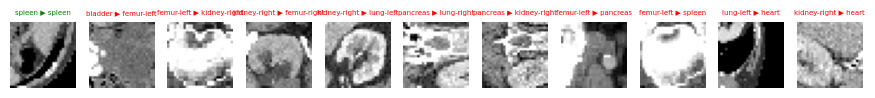

Training Loss: 0.8714 | Training Accuracy: 0.7466

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.7466 |   0.7466 |     0.7466 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.7409 |   0.7466 |     0.7396 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.7409 |   0.7466 |     0.7396 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 2/10


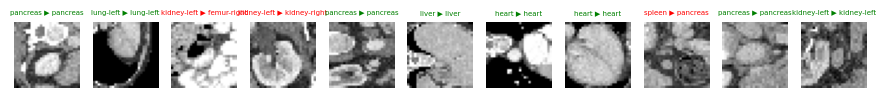

Training Loss: 0.4221 | Training Accuracy: 0.8678

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.8678 |   0.8678 |     0.8678 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.866  |   0.8678 |     0.8665 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.866  |   0.8678 |     0.8665 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 3/10


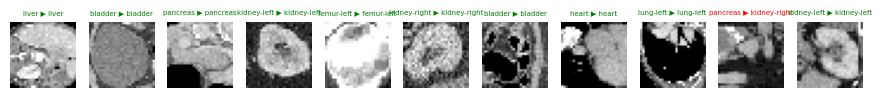

Training Loss: 0.2893 | Training Accuracy: 0.9073

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.9073 |   0.9073 |     0.9073 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.9068 |   0.9073 |     0.9069 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.9068 |   0.9073 |     0.9069 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 4/10


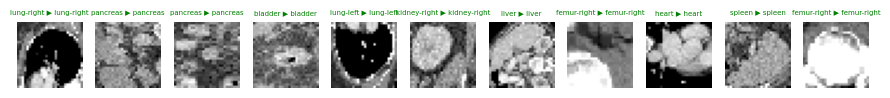

Training Loss: 0.2319 | Training Accuracy: 0.9254

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.9254 |   0.9254 |     0.9254 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.925  |   0.9254 |     0.9251 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.925  |   0.9254 |     0.9251 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 5/10


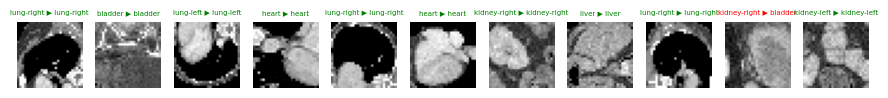

Training Loss: 0.1734 | Training Accuracy: 0.9459

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.9459 |   0.9459 |     0.9459 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.9457 |   0.9459 |     0.9457 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.9457 |   0.9459 |     0.9457 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 6/10


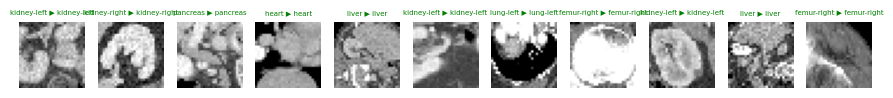

Training Loss: 0.1453 | Training Accuracy: 0.9541

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.9541 |   0.9541 |     0.9541 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.954  |   0.9541 |     0.954  |
+------------------+-------------+----------+------------+
| Weighted-average |      0.954  |   0.9541 |     0.954  |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 7/10


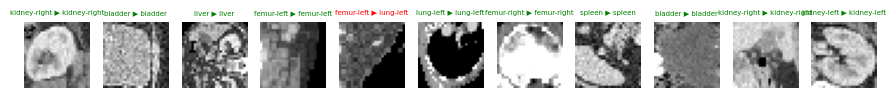

Training Loss: 0.1147 | Training Accuracy: 0.9636

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.9636 |   0.9636 |     0.9636 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.9635 |   0.9636 |     0.9635 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.9635 |   0.9636 |     0.9635 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 8/10


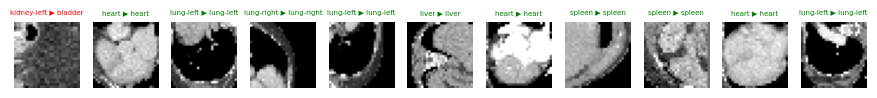

Training Loss: 0.1008 | Training Accuracy: 0.9660

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |       0.966 |    0.966 |      0.966 |
+------------------+-------------+----------+------------+
| Macro-average    |       0.966 |    0.966 |      0.966 |
+------------------+-------------+----------+------------+
| Weighted-average |       0.966 |    0.966 |      0.966 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 9/10


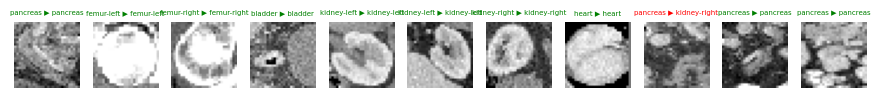

Training Loss: 0.0997 | Training Accuracy: 0.9676

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.9676 |   0.9676 |     0.9676 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.9676 |   0.9676 |     0.9676 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.9676 |   0.9676 |     0.9676 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 

Epoch 10/10


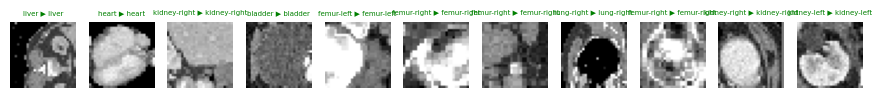

Training Loss: 0.0876 | Training Accuracy: 0.9723

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.9723 |   0.9723 |     0.9723 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.9723 |   0.9723 |     0.9723 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.9723 |   0.9723 |     0.9723 |
+------------------+-------------+----------+------------+
___________________________________________________________________________________ 



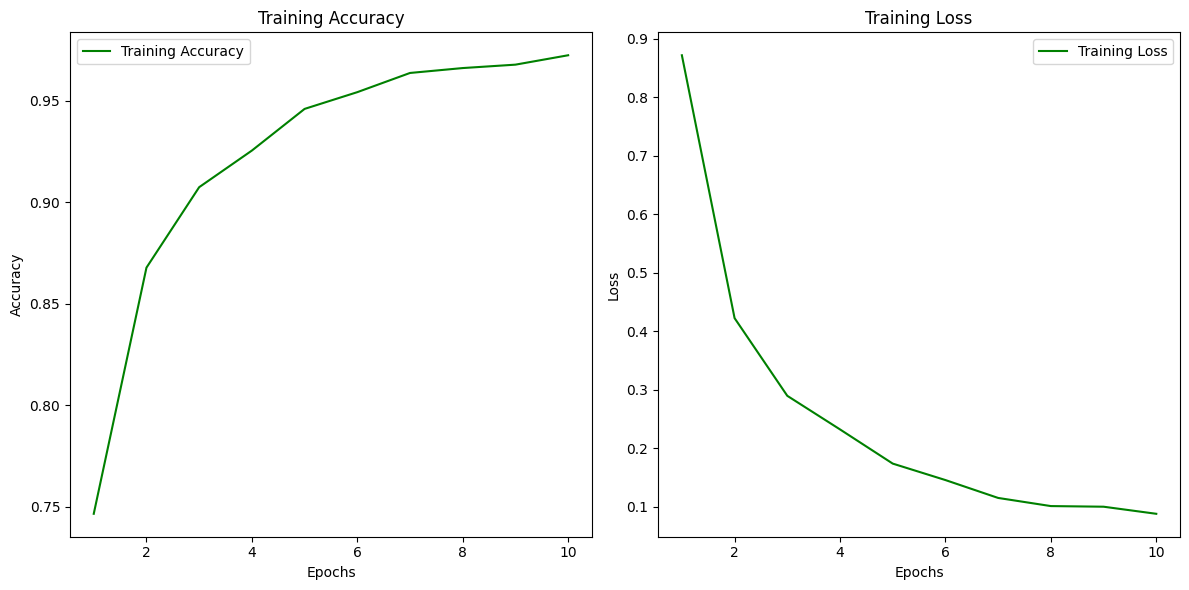

Saved the model to clean_models\clean_model-OrganAMNIST-dnn_model.pt


In [32]:
# Print the class name of the model
print(f"Target model: {type(target_model).__name__}")
print("___________________________________________________________________________________ \n")
# Start the timer
start_time = time.time()
train_model(target_model, filtered_train_loader, loss_fn, optimizer, num_epochs, device)
# End the timer
end_time = time.time()

In [33]:
# Calculate the training duration in seconds
training_duration_seconds = abs(end_time - start_time)
# Print the training duration
print(f"Training duration: {training_duration_seconds:.2f} seconds")

Training duration: 30.76 seconds



---
# 🧪 Model Evaluation

In [34]:
def load_clean_model(model, save_dir):
    # Model folder
    # model_path = f"{save_dir}/clean_model.pt"
    # model_path = f"{save_dir}/clean_model.pth"

    target_model_name = target_model.__class__.__name__.lower() + "_model"

    if target_model_name == 'qnn_model':
        filename = f"clean_model-{str(dataset_name)}-{str(target_model_name)}-{str(entanglement_type)}.pt"
    else:
        filename = f"clean_model-{str(dataset_name)}-{str(target_model_name)}.pt"

    model_path = os.path.join(save_dir, filename)

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found in {model_path}")

    # model = torch.load(model_path, weights_only=False)
    # model.load_state_dict(torch.load(model_path))

    model = torch.load(model_path, weights_only=False)  # weights_only param is rarely used, but kept as you had
    model.eval()

    print(f"Loaded model from {model_path}")
    return model

In [35]:
def evaluate(model, data_loader, loss_fn, device):
    global ODR
    test_loss = 0.0
    test_accuracy = 0.0
    num_misclassified = 0

    # Lists to store predictions and true labels for metric calculations
    all_labels = []
    all_predictions = []

    # Switch model to evaluation mode
    model.eval()

    misclassified_images = []
    misclassified_labels = []
    correctly_classified_images = []
    correctly_classified_labels = []
    misclassified_preds = []

    # Determine the total size of the dataset in the data_loader
    dataset_size = len(data_loader.dataset)
    print(f"Number of clean test images: {dataset_size}")

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        total_batches = 0
        for x, y in data_loader:
            # Move inputs/labels to the desired device
            x, y = x.to(device), y.to(device)
            y = y.squeeze()

            # Forward pass
            logits = model(x)

            # Calculate batch loss
            batch_loss = loss_fn(logits, y)
            test_loss += batch_loss.item()

            # Get predictions and calculate batch accuracy
            preds = torch.argmax(logits, dim=1)
            test_accuracy += torch.sum(preds == y).item()

            # Append predictions and labels to the lists
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            correct_inds = torch.where(preds == y)[0]
            if len(correct_inds) > 0:
                correctly_classified_images.append(x[correct_inds].cpu())
                correctly_classified_labels.append(y[correct_inds].cpu())

            # Track misclassified samples
            incorrect_inds = torch.where(preds != y)[0]
            num_misclassified += len(incorrect_inds)
            if len(incorrect_inds) > 0:
                # Move misclassified items to CPU
                misclassified_images.append(x[incorrect_inds].cpu())
                misclassified_labels.append(y[incorrect_inds].cpu())
                misclassified_preds.append(preds[incorrect_inds].cpu())

            total_batches += 1

    # Concatenate all correctly classified examples
    correct_images = torch.cat(correctly_classified_images)
    correct_labels = torch.cat(correctly_classified_labels)

    # Average loss over all batches
    test_loss /= total_batches
    # Accuracy over the entire dataset
    test_accuracy = test_accuracy / dataset_size

    ODR = test_accuracy

    # Print the summary
    print(f"Number of misclassified images: {num_misclassified} out of {dataset_size}")
    print(f"Test loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")
    print(f"ODR: {ODR:.2%}\n")

    # Calculate and print additional metrics
    micro_precision = precision_score(all_labels, all_predictions, average='micro', zero_division=0)
    micro_recall = recall_score(all_labels, all_predictions, average='micro', zero_division=0)
    micro_f1 = f1_score(all_labels, all_predictions, average='micro', zero_division=0)

    macro_precision = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
    macro_recall = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
    macro_f1 = f1_score(all_labels, all_predictions, average='macro', zero_division=0)

    weighted_precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    weighted_recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

    table_data = [
        ["Micro-average", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}"],
        ["Macro-average", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}"],
        ["Weighted-average", f"{weighted_precision:.4f}", f"{weighted_recall:.4f}", f"{weighted_f1:.4f}"]
    ]

    headers = ["Metric", "Precision", "Recall", "F1-Score"]
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

    # Handle edge cases if nothing is misclassified
    if len(misclassified_images) == 0:
        misclassified_images.append(torch.tensor([]))
    if len(misclassified_labels) == 0:
        misclassified_labels.append(torch.tensor([]))
    if len(misclassified_preds) == 0:
        misclassified_preds.append(torch.tensor([]))

    return (
        test_loss,
        test_accuracy,
        [torch.cat(misclassified_images)],
        [torch.cat(misclassified_labels)],
        [torch.cat(misclassified_preds)],
        correct_images,
        correct_labels
    )

In [36]:
# Model folder
save_dir = 'clean_models'
# Loading
clean_model = load_clean_model(target_model, save_dir)

Loaded model from clean_models\clean_model-OrganAMNIST-dnn_model.pt


In [37]:
# Start the timer
start_time = time.time()
# Evaluation
test_loss, test_acc, misclassified_images, misclassified_labels, misclassified_preds, correct_images, correct_labels = evaluate(
    clean_model, filtered_test_loader, loss_fn, device
)
# End the timer
end_time = time.time()

Number of clean test images: 8624
Number of misclassified images: 2432 out of 8624
Test loss: 1.0836 | Test Accuracy: 0.7180
ODR: 71.80%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.718  |    0.718 |     0.718  |
+------------------+-------------+----------+------------+
| Macro-average    |      0.7612 |    0.718 |     0.7291 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.7612 |    0.718 |     0.7291 |
+------------------+-------------+----------+------------+


In [38]:
# Calculate the attack duration in seconds
test_duration_seconds = abs(end_time - start_time)
# Print the test duration
print(f"Test duration: {test_duration_seconds:.2f} seconds")

Test duration: 0.89 seconds


In [39]:
def analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds):

    MAX_IMAGES_PER_CLASS = 5
    if len(misclassified_images) > 0:
        misclassified_images = misclassified_images[0]
        misclassified_labels = misclassified_labels[0]
        misclassified_preds = misclassified_preds[0]

        print(f"Number of misclassified images: {len(misclassified_images)}")

        # Initialize lists to store images by class
        images_by_class = [[] for _ in range(NUM_CLASSES)]
        labels_by_class = [[] for _ in range(NUM_CLASSES)]
        preds_by_class = [[] for _ in range(NUM_CLASSES)]

        # Group images by their true label
        for img, label, pred in zip(misclassified_images, misclassified_labels, misclassified_preds):
            if len(images_by_class[label]) < MAX_IMAGES_PER_CLASS:
                images_by_class[label].append(img)
                labels_by_class[label].append(label)
                preds_by_class[label].append(pred)

        num_images = MAX_IMAGES_PER_CLASS * NUM_CLASSES
        fig = plt.figure(figsize=(7, num_images // 16 + 2))  # Adjust figure size as needed

        for class_idx in range(NUM_CLASSES):
            for img_idx, (img, label, pred) in enumerate(zip(images_by_class[class_idx], labels_by_class[class_idx], preds_by_class[class_idx])):
                # Calculate the position in the grid
                pos = img_idx * NUM_CLASSES + class_idx + 1

                # Add subplot with NUM_CLASSES columns
                ax = fig.add_subplot(MAX_IMAGES_PER_CLASS, NUM_CLASSES, pos)

                # Add empty dim if needed
                if img.ndim == 2:
                    img = img[:, None, :, ]

                # Permute to HWC format for imshow
                img = img.permute(1, 2, 0)

                ax.imshow(img, cmap='gray')

                # Check if the label matches the prediction
                if label == pred:
                    title_color = 'green'  # Correct prediction
                else:
                    title_color = 'red'  # Incorrect prediction

                # Set the title with the chosen color
                ax.set_title(f"{label} ▶️ {pred}", color=title_color)
                ax.axis("off")

        plt.tight_layout()
        plt.show()

    else:
        print("No misclassified examples")

    return misclassified_images, misclassified_labels, misclassified_preds

Number of misclassified images: 2432


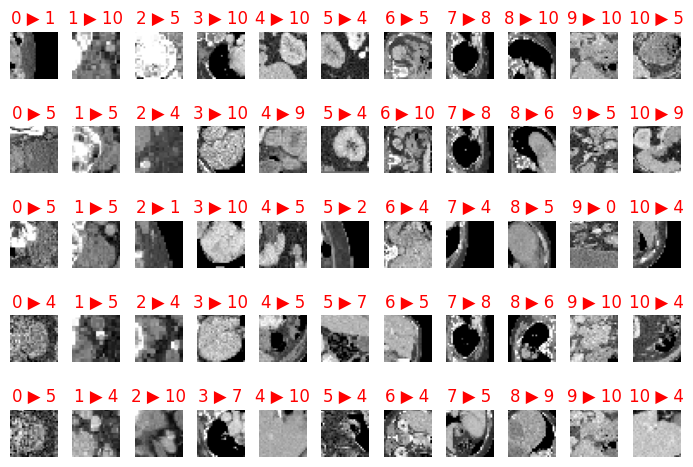

In [40]:
clean_misclassified_images, clean_misclassified_labels, clean_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [41]:
# Calculate the Total Time Cost (TTC) in seconds
ttc_seconds = abs(training_duration_seconds + test_duration_seconds)
# Print the TTC
print(f"TTC: {ttc_seconds:.2f} seconds")

TTC: 31.64 seconds



---
